Генерация выборки из распределения p(x|θ) = θ·(1-x)^(θ-1)

Цель работы
- Сгенерировать выборку из заданного распределения
- Оценить параметр θ методом максимального правдоподобия
- Построить доверительный интервал
- Сравнить эмпирическую и теоретическую плотности

Методы:
1. Генерация выборки методом обратного преобразования
2. Оценка параметра θ методом максимального правдоподобия (ОМП)
3. Построение асимптотического доверительного интервала
4. Визуальное сравнение эмпирической и теоретической плотностей

Распределение: f(x|θ) = θ·(1-x)^(θ-1), x ∈ [0,1], θ > 0
Это частный случай бета-распределения: Beta(1, θ)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Генерация выборки
np.random.seed(40)
theta = 2
n = 50

# Генерация из распределения p(X|θ) = θ(1-X)^(θ-1)
# Используем метод обратного преобразования
U = np.random.uniform(0, 1, n) #случайные числа из равномерного распределения
X = 1 - (1 - U)**(1/theta)

print(f"Выборочное среднее:    {np.mean(X):.4f}")
print(f"Выборочная дисперсия: {np.var(X, ddof=1):.4f}")
print(f"Теоретическое среднее: {1/(1+theta):.4f}")
print(f"Теоретическая дисперсия: {theta/((1+theta)**2 * (2+theta)):.4f}\n")

Выборочное среднее:    0.3365
Выборочная дисперсия: 0.0495
Теоретическое среднее: 0.3333
Теоретическая дисперсия: 0.0556



In [6]:
# Оценка максимального правдоподобия (ОМП)
''' 
Логарифмическая функция правдоподобия:
L(θ) = n·ln(θ) + (θ-1)·Σ ln(1-X_i)
θ_hat = -n / Σ ln(1-X_i)
'''

sum_log = np.sum(np.log(1 - X))
theta_hat = -n / sum_log

print(f"Оценка МП для θ: {theta_hat:.4f}")
print(f"Смещение: {theta_hat - theta:.4f}\n")

Оценка МП для θ: 2.0689
Смещение: 0.0689



In [7]:
# Асимптотический доверительный интервал (α = 0.05)
'''
# Асимптотическая дисперсия ОМП: D(θ_hat) ≈ θ² / n
# ДИ: θ_hat ± z_{1-α/2} · θ_hat / √n
'''
alpha = 0.05
z_quantile = stats.norm.ppf(1 - alpha/2)
se_mle = theta_hat / np.sqrt(n)  # стандартная ошибка

ci_lower = theta_hat - z_quantile * se_mle
ci_upper = theta_hat + z_quantile * se_mle

print(f"Доверительный интервал (α={alpha}): [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Попадает ли истинное значение? {'ДА' if ci_lower <= theta <= ci_upper else 'НЕТ'}\n")

Доверительный интервал (α=0.05): [1.4954, 2.6423]
Попадает ли истинное значение? ДА



In [9]:
# Альтернативная оценка: метод моментов (ММ)
# E[X] = 1/(1+θ) => θ_MM = 1/E[X] - 1

theta_mm = 1 / np.mean(X) - 1
print(f"Оценка методом моментов: {theta_mm:.4f}")


Оценка методом моментов: 1.9719


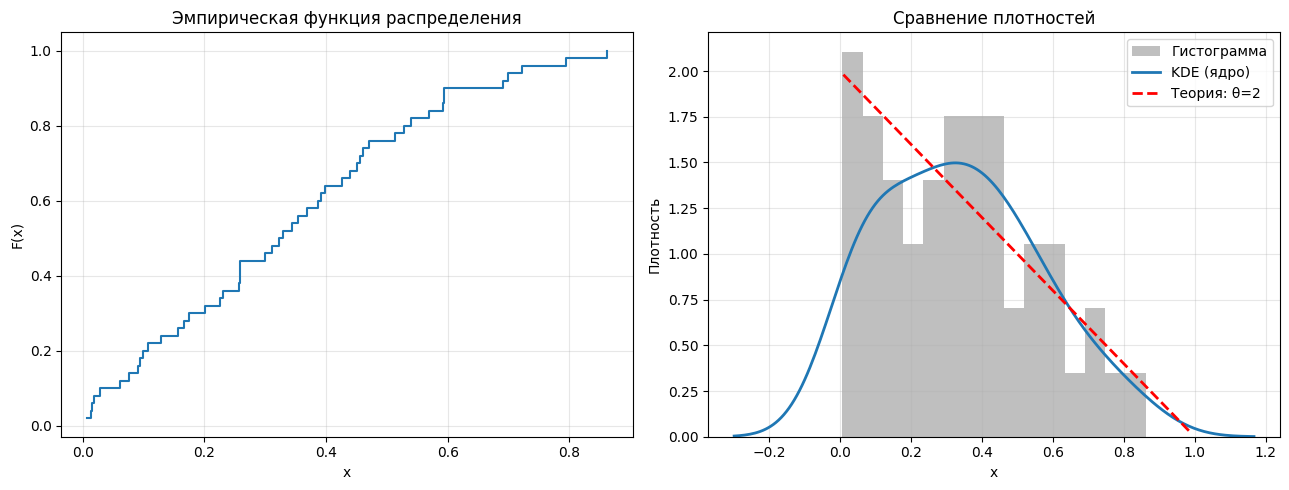

In [13]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Эмпирическая функция распределения (ECDF)
sorted_X = np.sort(X)
ecdf = np.arange(1, n + 1) / n
axes[0].step(sorted_X, ecdf, where='post', label='Эмпирическая CDF')
axes[0].set_xlabel('x')
axes[0].set_ylabel('F(x)')
axes[0].set_title('Эмпирическая функция распределения')
axes[0].grid(True, alpha=0.3)

# Сравнение плотностей (гистограмма + KDE + теория)
# Гистограмма
axes[1].hist(X, bins=15, density=True, alpha=0.5, color='gray', label='Гистограмма')

# Ядерная оценка плотности (KDE)
sns.kdeplot(X, ax=axes[1], label='KDE (ядро)', linewidth=2)

# Теоретическая плотность
x_plot = np.linspace(0.01, 0.99, 200)
f_theor = theta * (1 - x_plot) ** (theta - 1)
axes[1].plot(x_plot, f_theor, 'r--', linewidth=2, label=f'Теория: θ={theta}')

axes[1].set_xlabel('x')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Сравнение плотностей')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
print("КРАТКИЕ ВЫВОДЫ:")

if abs(theta_hat - theta) < 0.2:
    print("✓ ОМП дала точную оценку, близкую к истинному значению.")
else:
    print("⚠ ОМП дала оценку с заметным смещением (возможно, малая выборка).")

if ci_lower <= theta <= ci_upper:
    print("✓ Доверительный интервал накрыл истинное значение θ.")
else:
    print("⚠ Доверительный интервал не накрыл истинное значение (статистическая погрешность).")

print("\nГрафики показывают хорошее соответствие между:")
print("- эмпирической плотностью (гистограмма/KDE)")
print("- теоретической плотностью")
print("Это подтверждает корректность генерации данных.")

КРАТКИЕ ВЫВОДЫ:
✓ ОМП дала точную оценку, близкую к истинному значению.
✓ Доверительный интервал накрыл истинное значение θ.

Графики показывают хорошее соответствие между:
- эмпирической плотностью (гистограмма/KDE)
- теоретической плотностью
Это подтверждает корректность генерации данных.
